# PURITY Validation

Validates row alignment and computes basic event-level accuracy from inference output.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

from pioneerml.integration.zenml import utils as zenml_utils

PROJECT_ROOT = Path(zenml_utils.find_project_root()).resolve()
PLOTS_DIR = PROJECT_ROOT / 'artifacts' / 'validation_plots' / 'purity'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)


## Load Source + Predictions

In [2]:
# Configure these two paths for quick validation.
SOURCE_PATH = PROJECT_ROOT / 'data' / 'purity_inputs' / 'all_ml_000.parquet'
PRED_PATH = PROJECT_ROOT / 'artifacts' / 'purity_notebook_predictions' / 'all_ml_000_preds.parquet'

source_tbl = pq.read_table(SOURCE_PATH)
pred_tbl = pq.read_table(PRED_PATH)

print('source:', SOURCE_PATH)
print('pred  :', PRED_PATH)
print('source rows:', source_tbl.num_rows)
print('pred rows  :', pred_tbl.num_rows)
print('pred columns:', pred_tbl.column_names)

source = source_tbl.to_pydict()
pred = pred_tbl.to_pydict()

def list_scalar(x, *, reducer: str = 'first') -> float:
    def _flatten(vals):
        out = []
        stack = [vals]
        while stack:
            cur = stack.pop()
            if cur is None:
                continue
            if isinstance(cur, (list, tuple, np.ndarray)):
                stack.extend(list(cur)[::-1])
            else:
                try:
                    out.append(float(cur))
                except Exception:
                    continue
        return out

    vals = _flatten(x)
    if len(vals) == 0:
        return float('nan')
    if reducer == 'mean':
        return float(np.mean(vals))
    if reducer == 'max':
        return float(np.max(vals))
    if reducer == 'min':
        return float(np.min(vals))
    return float(vals[0])

source_event = np.asarray(source.get('event_id', []), dtype=np.int64)
truth_is_signal = np.asarray(source.get('truth_is_signal', np.zeros_like(source_event)), dtype=np.float32)
truth_energy = np.asarray(source.get('truth_positron_energy', np.full_like(source_event, np.nan, dtype=np.float32)), dtype=np.float32)
truth_theta = np.asarray(source.get('truth_theta', np.full_like(source_event, np.nan, dtype=np.float32)), dtype=np.float32)

truth_by_event = {
    int(e): {
        'is_signal': float(y),
        'positron_energy': float(en),
        'theta': float(th),
    }
    for e, y, en, th in zip(source_event, truth_is_signal, truth_energy, truth_theta, strict=True)
}

pred_event = np.asarray(pred.get('event_id', []), dtype=np.int64)

def col(name: str, reducer: str = 'first') -> np.ndarray:
    values = pred.get(name, [np.nan] * len(pred_event))
    return np.asarray([list_scalar(v, reducer=reducer) for v in values], dtype=np.float32)

pred_signal = col('pred_purity_signal', reducer='first')
pred_logit = col('pred_purity_logit', reducer='first')
pred_acc = col('pred_purity_summary_accepted', reducer='first')
pred_energy = col('pred_purity_summary_positron_energy', reducer='first')
pred_time = col('pred_purity_summary_positron_time', reducer='first')
pred_angle = col('pred_purity_summary_positron_polar_angle', reducer='first')
guard_valid = col('pred_purity_guard_valid', reducer='mean')
guard_reason = col('pred_purity_guard_reason', reducer='first')

valid_events = np.asarray([int(e) in truth_by_event for e in pred_event], dtype=bool)

true_sig = np.asarray([truth_by_event[int(e)]['is_signal'] if int(e) in truth_by_event else np.nan for e in pred_event], dtype=np.float32)
true_energy = np.asarray([truth_by_event[int(e)]['positron_energy'] if int(e) in truth_by_event else np.nan for e in pred_event], dtype=np.float32)
true_theta = np.asarray([truth_by_event[int(e)]['theta'] if int(e) in truth_by_event else np.nan for e in pred_event], dtype=np.float32)

sig_mask = np.isfinite(pred_signal) & np.isfinite(true_sig)
sig_acc = float(((pred_signal[sig_mask] >= 0.5).astype(np.float32) == (true_sig[sig_mask] > 0.5).astype(np.float32)).mean()) if np.any(sig_mask) else float('nan')

print('matched events:', int(valid_events.sum()), '/', int(pred_event.size))
print('signal@0.5 accuracy:', f'{sig_acc:.4f}' if np.isfinite(sig_acc) else 'nan')
print('guard valid mean:', float(np.nanmean(guard_valid)) if guard_valid.size else float('nan'))


source: /workspace/data/purity_inputs/all_ml_000.parquet /workspace/data/purity_inputs/all_ml_000.parquet
pred  : /workspace/artifacts/purity_notebook_predictions/all_ml_000_preds.parquet /workspace/artifacts/purity_notebook_predictions/all_ml_000_preds.parquet
source rows: 1024 1024
pred rows  : 1024 1024
pred columns: ['event_id', 'pred_purity_signal', 'pred_purity_logit', 'pred_purity_summary_accepted', 'pred_purity_summary_positron_energy', 'pred_purity_summary_positron_time', 'pred_purity_summary_positron_polar_angle', 'pred_purity_guard_valid', 'pred_purity_guard_reason', 'time_group_ids'] ['event_id', 'pred_purity_signal', 'pred_purity_logit', 'pred_purity_summary_accepted', 'pred_purity_summary_positron_energy', 'pred_purity_summary_positron_time', 'pred_purity_summary_positron_polar_angle', 'pred_purity_guard_valid', 'pred_purity_guard_reason', 'time_group_ids']
matched events: 1024 / 1024 1024 / 1024
signal@0.5 accuracy: 0.1603 0.1603
guard valid mean: 0.9912023544311523 0.99

## Quick Diagnostic Plot

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
saved: /workspace/artifacts/validation_plots/purity/purity_validation_diagnostics.png /workspace/artifacts/validation_plots/purity/purity_validation_diagnostics.png


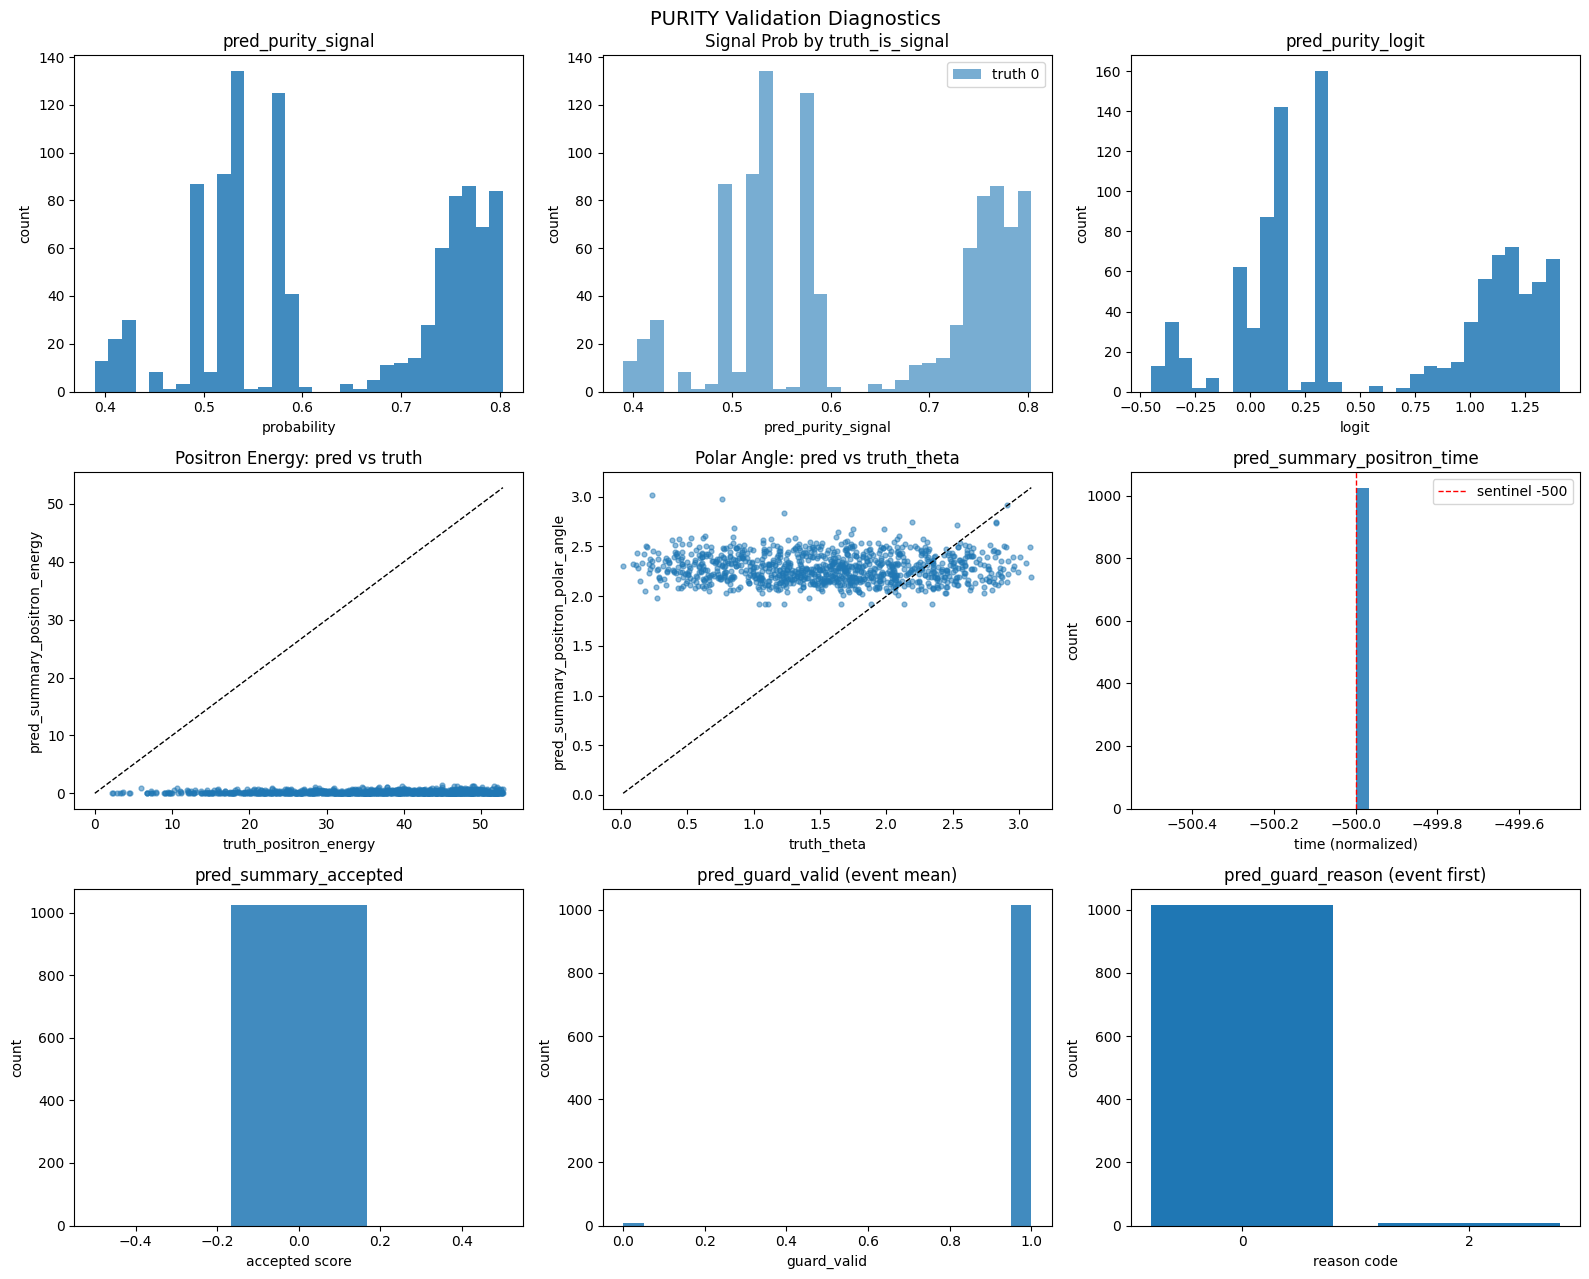

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.reshape(-1)

# 1) Signal probability distribution
m = np.isfinite(pred_signal)
axes[0].hist(pred_signal[m], bins=30, alpha=0.85)
axes[0].set_title('pred_purity_signal')
axes[0].set_xlabel('probability')
axes[0].set_ylabel('count')

# 2) Signal by truth class
m0 = np.isfinite(pred_signal) & np.isfinite(true_sig) & (true_sig <= 0.5)
m1 = np.isfinite(pred_signal) & np.isfinite(true_sig) & (true_sig > 0.5)
if np.any(m0):
    axes[1].hist(pred_signal[m0], bins=30, alpha=0.6, label='truth 0')
if np.any(m1):
    axes[1].hist(pred_signal[m1], bins=30, alpha=0.6, label='truth 1')
axes[1].set_title('Signal Prob by truth_is_signal')
axes[1].set_xlabel('pred_purity_signal')
axes[1].set_ylabel('count')
if np.any(m0) or np.any(m1):
    axes[1].legend()

# 3) Logit distribution
m = np.isfinite(pred_logit)
axes[2].hist(pred_logit[m], bins=30, alpha=0.85)
axes[2].set_title('pred_purity_logit')
axes[2].set_xlabel('logit')
axes[2].set_ylabel('count')

# 4) Positron energy: pred vs truth
m = np.isfinite(pred_energy) & np.isfinite(true_energy)
if np.any(m):
    axes[3].scatter(true_energy[m], pred_energy[m], s=12, alpha=0.5)
    lo = float(np.nanmin(np.r_[true_energy[m], pred_energy[m]]))
    hi = float(np.nanmax(np.r_[true_energy[m], pred_energy[m]]))
    axes[3].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[3].set_title('Positron Energy: pred vs truth')
axes[3].set_xlabel('truth_positron_energy')
axes[3].set_ylabel('pred_summary_positron_energy')

# 5) Positron polar angle: pred vs truth_theta
m = np.isfinite(pred_angle) & np.isfinite(true_theta) & (pred_angle > -900)
if np.any(m):
    axes[4].scatter(true_theta[m], pred_angle[m], s=12, alpha=0.5)
    lo = float(np.nanmin(np.r_[true_theta[m], pred_angle[m]]))
    hi = float(np.nanmax(np.r_[true_theta[m], pred_angle[m]]))
    axes[4].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[4].set_title('Polar Angle: pred vs truth_theta')
axes[4].set_xlabel('truth_theta')
axes[4].set_ylabel('pred_summary_positron_polar_angle')

# 6) Positron time distribution (with sentinel marker)
m = np.isfinite(pred_time)
axes[5].hist(pred_time[m], bins=30, alpha=0.85)
axes[5].axvline(-500.0, color='r', ls='--', lw=1, label='sentinel -500')
axes[5].set_title('pred_summary_positron_time')
axes[5].set_xlabel('time (normalized)')
axes[5].set_ylabel('count')
axes[5].legend()

# 7) Accepted distribution
m = np.isfinite(pred_acc)
axes[6].hist(pred_acc[m], bins=3, alpha=0.85)
axes[6].set_title('pred_summary_accepted')
axes[6].set_xlabel('accepted score')
axes[6].set_ylabel('count')

# 8) Guard valid distribution
m = np.isfinite(guard_valid)
axes[7].hist(guard_valid[m], bins=20, alpha=0.85)
axes[7].set_title('pred_guard_valid (event mean)')
axes[7].set_xlabel('guard_valid')
axes[7].set_ylabel('count')

# 9) Guard reason counts
m = np.isfinite(guard_reason)
if np.any(m):
    reasons = guard_reason[m].astype(np.int64)
    uniq, cnt = np.unique(reasons, return_counts=True)
    axes[8].bar(uniq.astype(str), cnt)
axes[8].set_title('pred_guard_reason (event first)')
axes[8].set_xlabel('reason code')
axes[8].set_ylabel('count')

fig.suptitle('PURITY Validation Diagnostics', fontsize=14)
plt.tight_layout()
out_path = PLOTS_DIR / 'purity_validation_diagnostics.png'
fig.savefig(out_path, dpi=150)
print('saved:', out_path)
plt.show()
